# NB07: Pangenome Conservation & Lung Adaptation

**Project**: CF Protective Microbiome Formulation Design  
**Goal**: Test H5 (are metabolic competition properties conserved across species?) and H6 (do lung-associated genomes show distinct metabolic signatures?).

For the 5 core FDA-safe commensal species (Neisseria mucosa, Streptococcus salivarius, Micrococcus luteus, Rothia dentocariosa, Gemella sanguinis), we ask:
1. How conserved are GapMind carbon/amino acid pathways within each species?
2. Are there lung/respiratory genomes in the pangenome for these species?
3. If so, do lung genomes differ metabolically from non-lung members?

**Requires**: BERDL Spark access (on JupyterHub)

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Spark session — JupyterHub CLI requires explicit import
from berdl_notebook_utils.setup_spark_session import get_spark_session
spark = get_spark_session()

DATA = Path('/home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/data')
FIGS = Path('/home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/figures')
GOLD = Path.home() / 'protect' / 'gold'

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

isolates = pd.read_parquet(GOLD / 'dim_isolate.snappy.parquet')
print(f'Spark session ready. Isolate catalog: {len(isolates)}')

Spark session ready. Isolate catalog: 4949


## 1. Link Core Species to Pangenome

Map our 5 core commensal species from PROTECT isolates → reference genome accession → pangenome species clade.

In [2]:
# Core species from NB05b
core_species = [
    'Neisseria mucosa',
    'Streptococcus salivarius',
    'Micrococcus luteus',
    'Rothia dentocariosa',
    'Gemella sanguinis',
]

# Get reference genome accessions for each
core_refs = isolates[isolates.species.isin(core_species)][['species','closest_genome_reference']].drop_duplicates()
print('Core species reference genomes:')
print(core_refs.to_string(index=False))

# These are GCF_* accessions — pangenome uses RS_GCF_* prefix
ref_accessions = core_refs.closest_genome_reference.unique().tolist()
ref_with_prefix = [f'RS_{a}' for a in ref_accessions]
print(f'\nPangenome genome IDs to search: {ref_with_prefix}')

Core species reference genomes:
                 species closest_genome_reference
     Rothia dentocariosa          GCF_000164695.2
Streptococcus salivarius          GCF_000785515.1
       Gemella sanguinis          GCF_000701685.1
      Micrococcus luteus          GCF_000023205.1
        Neisseria mucosa          GCA_003028315.1

Pangenome genome IDs to search: ['RS_GCF_000164695.2', 'RS_GCF_000785515.1', 'RS_GCF_000701685.1', 'RS_GCF_000023205.1', 'RS_GCA_003028315.1']


In [3]:
# Find species clades for our reference genomes
ref_list = "','".join(ref_with_prefix)
clade_df = spark.sql(f"""
    SELECT genome_id, gtdb_species_clade_id
    FROM kbase_ke_pangenome.genome
    WHERE genome_id IN ('{ref_list}')
""").toPandas()

# Also try GB_ prefix in case some are GenBank
ref_gb = [f'GB_GCA_{a[4:]}' for a in ref_accessions]  # GCF -> GCA with GB_ prefix
ref_gb_list = "','".join(ref_gb)
clade_gb = spark.sql(f"""
    SELECT genome_id, gtdb_species_clade_id
    FROM kbase_ke_pangenome.genome
    WHERE genome_id IN ('{ref_gb_list}')
""").toPandas()

clade_all = pd.concat([clade_df, clade_gb]).drop_duplicates()
print(f'Found {len(clade_all)} genome-to-clade mappings:')
print(clade_all.to_string(index=False))

# If direct lookup fails, search by species name
if len(clade_all) < len(core_species):
    print('\nSome species not found by accession. Searching by species name...')
    for sp in core_species:
        # Convert to GTDB format: s__Genus_species
        parts = sp.split()
        gtdb_prefix = f's__{parts[0]}_{parts[1]}' if len(parts) >= 2 else f's__{parts[0]}'
        found = spark.sql(f"""
            SELECT DISTINCT gtdb_species_clade_id
            FROM kbase_ke_pangenome.genome
            WHERE gtdb_species_clade_id LIKE '{gtdb_prefix}%'
            LIMIT 5
        """).toPandas()
        if len(found) > 0:
            print(f'  {sp} -> {found.gtdb_species_clade_id.tolist()}')
        else:
            print(f'  {sp} -> NOT FOUND in pangenome')

Found 5 genome-to-clade mappings:
         genome_id                           gtdb_species_clade_id
RS_GCF_000164695.2      s__Rothia_dentocariosa--RS_GCF_000164695.2
RS_GCF_000701685.1        s__Gemella_sanguinis--RS_GCF_000701685.1
RS_GCF_000023205.1       s__Micrococcus_luteus--RS_GCF_000023205.1
RS_GCF_000785515.1 s__Streptococcus_salivarius--RS_GCF_000785515.1
GB_GCA_003028315.1         s__Neisseria_mucosa--GB_GCA_003028315.1


In [4]:
# Build species -> clade mapping
# Collect all clade IDs we found
species_clades = {}
for sp in core_species:
    parts = sp.split()
    gtdb_prefix = f's__{parts[0]}_{parts[1]}' if len(parts) >= 2 else f's__{parts[0]}'
    clades = spark.sql(f"""
        SELECT DISTINCT gtdb_species_clade_id
        FROM kbase_ke_pangenome.genome
        WHERE gtdb_species_clade_id LIKE '{gtdb_prefix}%'
    """).toPandas()
    species_clades[sp] = clades.gtdb_species_clade_id.tolist()

# Get genome counts per clade
print('Species clade mapping:')
for sp, clades in species_clades.items():
    for clade in clades[:3]:  # show first 3 if multiple
        count = spark.sql(f"""
            SELECT COUNT(*) as n FROM kbase_ke_pangenome.genome
            WHERE gtdb_species_clade_id = '{clade}'
        """).toPandas().iloc[0]['n']
        print(f'  {sp} -> {clade} ({count} genomes)')

Species clade mapping:


  Neisseria mucosa -> s__Neisseria_mucosa_A--RS_GCF_003044445.1 (15 genomes)


  Neisseria mucosa -> s__Neisseria_mucosa--GB_GCA_003028315.1 (8 genomes)


  Streptococcus salivarius -> s__Streptococcus_salivarius--RS_GCF_000785515.1 (153 genomes)


  Micrococcus luteus -> s__Micrococcus_luteus--RS_GCF_000023205.1 (295 genomes)


  Rothia dentocariosa -> s__Rothia_dentocariosa--RS_GCF_000164695.2 (29 genomes)


  Gemella sanguinis -> s__Gemella_sanguinis--RS_GCF_000701685.1 (7 genomes)


## 2. GapMind Pathway Conservation

For each core species clade, extract GapMind pathway predictions and compute:
- What fraction of genomes have each pathway complete/likely_complete?
- Are amino acid catabolism and carbon utilization pathways conserved or variable?

In [5]:
# Extract GapMind pathway conservation for each species
# Use clade_name (= gtdb_species_clade_id) filter
# MAX score per genome-pathway pair (multiple rows per pair)
# Score hierarchy: complete=5, likely_complete=4, steps_missing_low=3, steps_missing_medium=2, not_present=1

conservation_results = []

for sp, clades in species_clades.items():
    for clade in clades[:1]:  # use primary clade
        print(f'Querying GapMind for {sp} ({clade})...')
        gm = spark.sql(f"""
            WITH scored AS (
                SELECT genome_id, pathway, metabolic_category,
                    CASE score_category
                        WHEN 'complete' THEN 5
                        WHEN 'likely_complete' THEN 4
                        WHEN 'steps_missing_low' THEN 3
                        WHEN 'steps_missing_medium' THEN 2
                        WHEN 'not_present' THEN 1
                        ELSE 0
                    END AS score_val
                FROM kbase_ke_pangenome.gapmind_pathways
                WHERE clade_name = '{clade}'
            ),
            best AS (
                SELECT genome_id, pathway, metabolic_category,
                    MAX(score_val) AS best_score
                FROM scored
                GROUP BY genome_id, pathway, metabolic_category
            )
            SELECT pathway, metabolic_category,
                COUNT(DISTINCT genome_id) AS n_genomes,
                CAST(AVG(CASE WHEN best_score >= 4 THEN 1.0 ELSE 0.0 END) AS DOUBLE) AS frac_complete,
                CAST(AVG(CASE WHEN best_score >= 3 THEN 1.0 ELSE 0.0 END) AS DOUBLE) AS frac_functional,
                CAST(AVG(best_score) AS DOUBLE) AS mean_score
            FROM best
            GROUP BY pathway, metabolic_category
            ORDER BY metabolic_category, frac_complete DESC
        """).toPandas()
        gm['species'] = sp
        gm['clade'] = clade
        conservation_results.append(gm)
        print(f'  {len(gm)} pathways, {gm.n_genomes.iloc[0] if len(gm) > 0 else 0} genomes')

conservation = pd.concat(conservation_results, ignore_index=True)
print(f'\nTotal: {len(conservation)} species × pathway combinations')

Querying GapMind for Neisseria mucosa (s__Neisseria_mucosa_A--RS_GCF_003044445.1)...


  80 pathways, 15 genomes
Querying GapMind for Streptococcus salivarius (s__Streptococcus_salivarius--RS_GCF_000785515.1)...


  80 pathways, 153 genomes
Querying GapMind for Micrococcus luteus (s__Micrococcus_luteus--RS_GCF_000023205.1)...


  80 pathways, 295 genomes
Querying GapMind for Rothia dentocariosa (s__Rothia_dentocariosa--RS_GCF_000164695.2)...


  80 pathways, 29 genomes
Querying GapMind for Gemella sanguinis (s__Gemella_sanguinis--RS_GCF_000701685.1)...


  80 pathways, 7 genomes

Total: 400 species × pathway combinations


In [6]:
# Summary: pathway conservation by species
for sp in core_species:
    sp_data = conservation[conservation.species == sp]
    if len(sp_data) == 0:
        print(f'\n{sp}: No GapMind data found')
        continue
    n_genomes = sp_data.n_genomes.iloc[0]
    
    # Amino acid pathways
    aa = sp_data[sp_data.metabolic_category == 'aa']
    carbon = sp_data[sp_data.metabolic_category == 'carbon']
    
    print(f'\n{sp} ({n_genomes} genomes):')
    print(f'  Amino acid pathways: {len(aa)}')
    if len(aa) > 0:
        print(f'    Universally complete (>95%): {(aa.frac_complete > 0.95).sum()}')
        print(f'    Variable (10-90% complete):  {((aa.frac_complete > 0.1) & (aa.frac_complete < 0.9)).sum()}')
        print(f'    Absent (<10% complete):      {(aa.frac_complete < 0.1).sum()}')
    print(f'  Carbon pathways: {len(carbon)}')
    if len(carbon) > 0:
        print(f'    Universally complete (>95%): {(carbon.frac_complete > 0.95).sum()}')
        print(f'    Variable (10-90% complete):  {((carbon.frac_complete > 0.1) & (carbon.frac_complete < 0.9)).sum()}')
        print(f'    Absent (<10% complete):      {(carbon.frac_complete < 0.1).sum()}')


Neisseria mucosa (15 genomes):
  Amino acid pathways: 18
    Universally complete (>95%): 16
    Variable (10-90% complete):  0
    Absent (<10% complete):      0
  Carbon pathways: 62
    Universally complete (>95%): 27
    Variable (10-90% complete):  0
    Absent (<10% complete):      23

Streptococcus salivarius (153 genomes):
  Amino acid pathways: 18
    Universally complete (>95%): 18
    Variable (10-90% complete):  0
    Absent (<10% complete):      0
  Carbon pathways: 62
    Universally complete (>95%): 32
    Variable (10-90% complete):  3
    Absent (<10% complete):      25

Micrococcus luteus (295 genomes):
  Amino acid pathways: 18
    Universally complete (>95%): 18
    Variable (10-90% complete):  0
    Absent (<10% complete):      0
  Carbon pathways: 62
    Universally complete (>95%): 39
    Variable (10-90% complete):  0
    Absent (<10% complete):      23

Rothia dentocariosa (29 genomes):
  Amino acid pathways: 18
    Universally complete (>95%): 14
    Variable

## 2.1 N. mucosa Clade Sensitivity Check

The pangenome contains two *N. mucosa* clades:
- `s__Neisseria_mucosa_A` (15 genomes) — used in the primary analysis above
- `s__Neisseria_mucosa` (8 genomes) — contains the PROTECT isolate reference genome `GB_GCA_003028315.1`

Since our PROTECT isolate maps to the smaller clade, we should verify that conservation results hold for that clade as well.

In [7]:
# N. mucosa clade sensitivity check
# Primary analysis used s__Neisseria_mucosa_A (15 genomes)
# But the PROTECT isolate reference genome (GCA_003028315.1) maps to
# s__Neisseria_mucosa (8 genomes). Compare conservation between clades.

alt_clade = 's__Neisseria_mucosa--GB_GCA_003028315.1'
primary_clade = 's__Neisseria_mucosa_A--RS_GCF_003044445.1'

print(f'Querying GapMind for alternate N. mucosa clade ({alt_clade})...')
alt_gm = spark.sql(f"""
    WITH scored AS (
        SELECT genome_id, pathway, metabolic_category,
            CASE score_category
                WHEN 'complete' THEN 5 WHEN 'likely_complete' THEN 4
                WHEN 'steps_missing_low' THEN 3 WHEN 'steps_missing_medium' THEN 2
                WHEN 'not_present' THEN 1 ELSE 0
            END AS score_val
        FROM kbase_ke_pangenome.gapmind_pathways
        WHERE clade_name = '{alt_clade}'
    ),
    best AS (
        SELECT genome_id, pathway, metabolic_category,
            MAX(score_val) AS best_score
        FROM scored
        GROUP BY genome_id, pathway, metabolic_category
    )
    SELECT pathway, metabolic_category,
        COUNT(DISTINCT genome_id) AS n_genomes,
        CAST(AVG(CASE WHEN best_score >= 4 THEN 1.0 ELSE 0.0 END) AS DOUBLE) AS frac_complete,
        CAST(AVG(best_score) AS DOUBLE) AS mean_score
    FROM best
    GROUP BY pathway, metabolic_category
    ORDER BY metabolic_category, frac_complete DESC
""").toPandas()

print(f'Alternate clade: {alt_gm.n_genomes.iloc[0] if len(alt_gm) > 0 else 0} genomes, {len(alt_gm)} pathways')

# Compare AA pathway conservation between the two clades
primary_cons = conservation[(conservation.species == 'Neisseria mucosa') & (conservation.metabolic_category == 'aa')]
alt_aa = alt_gm[alt_gm.metabolic_category == 'aa']

print(f'\n=== N. mucosa AA Pathway Conservation: Clade Comparison ===')
print(f'{"Pathway":<20} {"_A clade (15g)":<18} {"PROTECT clade (8g)":<20} {"Diff":<8}')
print('-' * 70)
for _, row in primary_cons.iterrows():
    pw = row.pathway
    prim_frac = row.frac_complete
    alt_row = alt_aa[alt_aa.pathway == pw]
    alt_frac = alt_row.frac_complete.iloc[0] if len(alt_row) > 0 else float('nan')
    diff = alt_frac - prim_frac if not pd.isna(alt_frac) else float('nan')
    marker = ' ←' if alt_frac > prim_frac + 0.01 else (' →' if prim_frac > alt_frac + 0.01 else '')
    print(f'{pw:<20} {prim_frac:<18.2%} {alt_frac:<20.2%} {diff:+.2%}{marker}')

# Carbon pathways
primary_carbon = conservation[(conservation.species == 'Neisseria mucosa') & (conservation.metabolic_category == 'carbon')]
alt_carbon = alt_gm[alt_gm.metabolic_category == 'carbon']

prim_aa_95 = (primary_cons.frac_complete > 0.95).sum()
alt_aa_95 = (alt_aa.frac_complete > 0.95).sum()
prim_c_95 = (primary_carbon.frac_complete > 0.95).sum()
alt_c_95 = (alt_carbon.frac_complete > 0.95).sum()

print(f'\n=== Summary ===')
print(f'AA pathways >95% conserved: _A clade = {prim_aa_95}/18, PROTECT clade = {alt_aa_95}/18')
print(f'Carbon pathways >95% conserved: _A clade = {prim_c_95}/62, PROTECT clade = {alt_c_95}/62')

if alt_aa_95 >= prim_aa_95:
    print(f'\n✓ The PROTECT isolate clade shows EQUAL OR STRONGER conservation.')
    print(f'  Conservation claims in the primary analysis are, if anything, UNDERSTATED.')
else:
    print(f'\n⚠ The PROTECT isolate clade shows WEAKER conservation on {prim_aa_95 - alt_aa_95} AA pathways.')
    print(f'  The primary analysis may overstate conservation for N. mucosa.')

Querying GapMind for alternate N. mucosa clade (s__Neisseria_mucosa--GB_GCA_003028315.1)...


Alternate clade: 8 genomes, 80 pathways

=== N. mucosa AA Pathway Conservation: Clade Comparison ===
Pathway              _A clade (15g)     PROTECT clade (8g)   Diff    
----------------------------------------------------------------------
gly                  100.00%            100.00%              +0.00%
leu                  100.00%            100.00%              +0.00%
phe                  100.00%            100.00%              +0.00%
chorismate           100.00%            100.00%              +0.00%
pro                  100.00%            100.00%              +0.00%
ile                  100.00%            100.00%              +0.00%
lys                  100.00%            100.00%              +0.00%
thr                  100.00%            100.00%              +0.00%
asn                  100.00%            100.00%              +0.00%
arg                  100.00%            100.00%              +0.00%
val                  100.00%            100.00%              +0.00%
met       

In [8]:
# Get environment metadata for genomes in our clades
# genome.ncbi_biosample_id joins directly to ncbi_env.accession
env_results = []

for sp, clades in species_clades.items():
    for clade in clades[:1]:
        print(f'Querying environment for {sp}...')
        try:
            env = spark.sql(f"""
                SELECT g.genome_id, g.ncbi_biosample_id, n.harmonized_name, n.content
                FROM kbase_ke_pangenome.genome g
                JOIN kbase_ke_pangenome.ncbi_env n ON g.ncbi_biosample_id = n.accession
                WHERE g.gtdb_species_clade_id = '{clade}'
                  AND n.harmonized_name IN ('isolation_source', 'host', 'host_disease', 'env_broad_scale', 'tissue')
            """).toPandas()
            env['species'] = sp
            env['clade'] = clade
            env_results.append(env)
            print(f'  {len(env)} metadata records for {env.genome_id.nunique()} genomes')
        except Exception as e:
            print(f'  Error: {str(e)[:200]}')

if env_results:
    env_all = pd.concat(env_results, ignore_index=True)
    print(f'\nTotal environment records: {len(env_all)}')
else:
    env_all = pd.DataFrame()
    print('No environment data found.')

Querying environment for Neisseria mucosa...


  35 metadata records for 15 genomes
Querying environment for Streptococcus salivarius...


  325 metadata records for 143 genomes
Querying environment for Micrococcus luteus...


  562 metadata records for 293 genomes
Querying environment for Rothia dentocariosa...


  58 metadata records for 28 genomes
Querying environment for Gemella sanguinis...


  13 metadata records for 5 genomes

Total environment records: 993


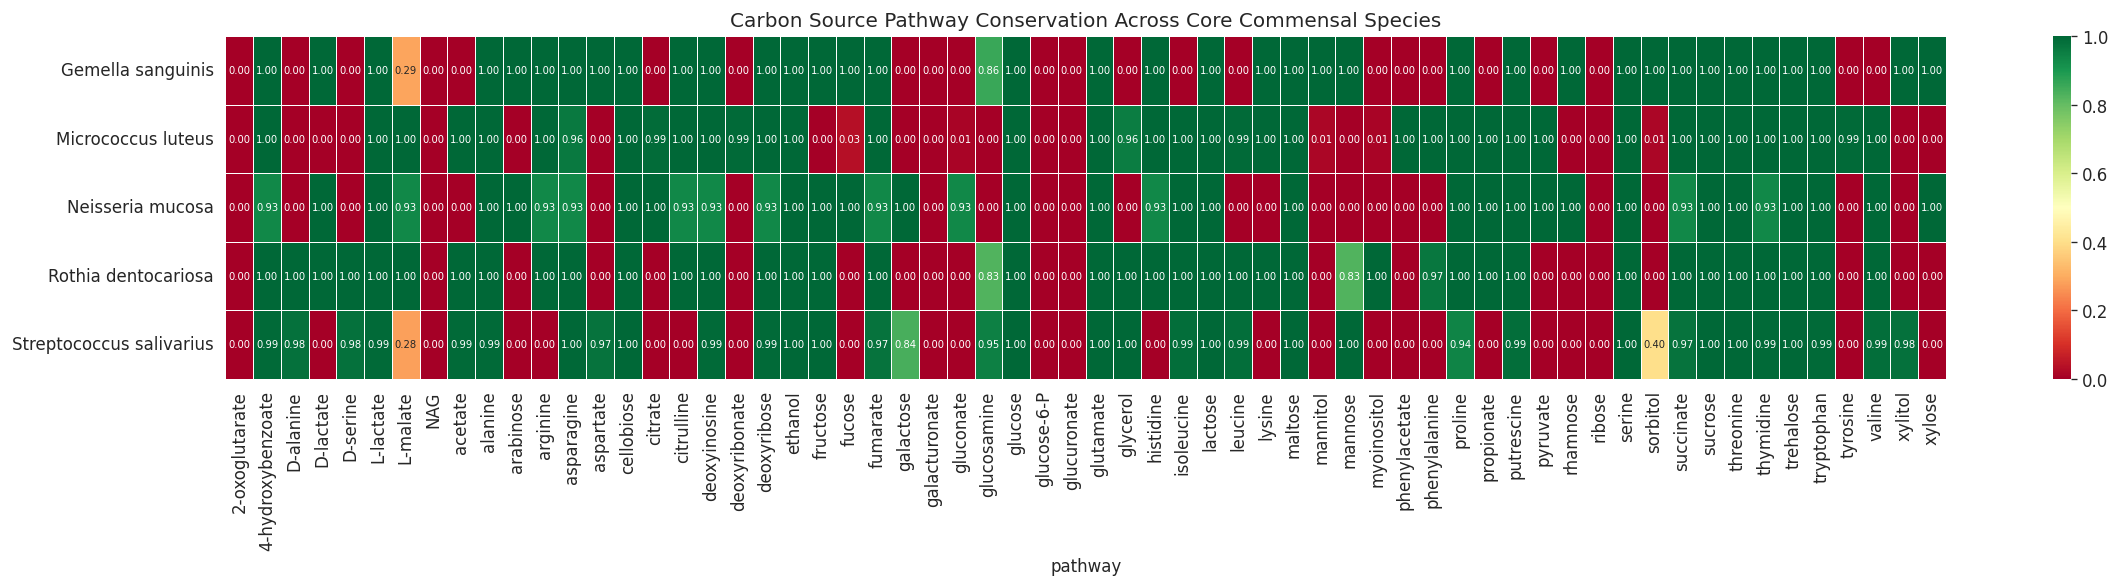

In [9]:
# Carbon source pathway conservation
carbon_data = conservation[conservation.metabolic_category == 'carbon']
if len(carbon_data) > 0:
    carbon_pivot = carbon_data.pivot_table(index='species', columns='pathway', values='frac_complete')
    
    fig, ax = plt.subplots(figsize=(20, 5))
    sns.heatmap(carbon_pivot, cmap='RdYlGn', vmin=0, vmax=1, linewidths=0.5, ax=ax,
                annot=True, fmt='.2f', annot_kws={'size': 6})
    ax.set_title('Carbon Source Pathway Conservation Across Core Commensal Species')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig(FIGS / '07_carbon_pathway_conservation.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No carbon pathway data to plot.')

## 3. Environmental Source: Are There Lung Genomes?

Query `ncbi_env` (EAV format) for isolation_source of genomes in our core species clades. Look for lung, respiratory, sputum, oral, or CF-related samples.

In [10]:
# Categorize isolation sources
if len(env_all) > 0:
    iso_source = env_all[env_all.harmonized_name == 'isolation_source'].copy()
    
    # Classify into broad categories
    def classify_source(text):
        if pd.isna(text):
            return 'Unknown'
        t = str(text).lower()
        if any(x in t for x in ['lung', 'sputum', 'respiratory', 'bronch', 'trachea', 'nasopharyn', 'pulmonary']):
            return 'Lung/Respiratory'
        if any(x in t for x in ['oral', 'mouth', 'saliva', 'dental', 'tongue', 'throat', 'pharyn', 'tonsil']):
            return 'Oral'
        if any(x in t for x in ['blood', 'wound', 'abscess', 'csf', 'urine']):
            return 'Clinical/Invasive'
        if any(x in t for x in ['gut', 'fecal', 'stool', 'intestin', 'colon', 'rectal']):
            return 'Gut'
        if any(x in t for x in ['skin', 'nasal', 'nares', 'ear']):
            return 'Skin/Nasal'
        if any(x in t for x in ['soil', 'water', 'marine', 'freshwater', 'sediment', 'environ']):
            return 'Environmental'
        if any(x in t for x in ['human', 'homo sapiens', 'patient']):
            return 'Human (unspecified)'
        return 'Other'
    
    iso_source['category'] = iso_source.content.apply(classify_source)
    
    print('Isolation source categories per species:')
    for sp in core_species:
        sp_data = iso_source[iso_source.species == sp]
        if len(sp_data) == 0:
            print(f'\n{sp}: No isolation source data')
            continue
        cats = sp_data.groupby('category')['genome_id'].nunique().sort_values(ascending=False)
        total = sp_data.genome_id.nunique()
        print(f'\n{sp} ({total} genomes with source data):')
        for cat, n in cats.items():
            print(f'  {cat}: {n} ({n/total:.0%})')
    
    # Specifically: how many lung/respiratory genomes?
    lung_genomes = iso_source[iso_source.category == 'Lung/Respiratory']
    print(f'\n=== LUNG/RESPIRATORY GENOMES ===')
    print(f'Total across all species: {lung_genomes.genome_id.nunique()}')
    for sp in core_species:
        n = lung_genomes[lung_genomes.species == sp].genome_id.nunique()
        print(f'  {sp}: {n}')
else:
    print('No environment data to categorize.')

Isolation source categories per species:

Neisseria mucosa (15 genomes with source data):
  Other: 7 (47%)
  Lung/Respiratory: 5 (33%)
  Environmental: 2 (13%)
  Oral: 1 (7%)

Streptococcus salivarius (121 genomes with source data):
  Other: 40 (33%)
  Gut: 32 (26%)
  Oral: 23 (19%)
  Clinical/Invasive: 15 (12%)
  Lung/Respiratory: 5 (4%)
  Human (unspecified): 3 (2%)
  Environmental: 2 (2%)
  Skin/Nasal: 1 (1%)

Micrococcus luteus (276 genomes with source data):
  Other: 188 (68%)
  Environmental: 42 (15%)
  Skin/Nasal: 38 (14%)
  Oral: 3 (1%)
  Clinical/Invasive: 2 (1%)
  Gut: 2 (1%)
  Human (unspecified): 1 (0%)

Rothia dentocariosa (26 genomes with source data):
  Other: 13 (50%)
  Lung/Respiratory: 10 (38%)
  Oral: 3 (12%)

Gemella sanguinis (5 genomes with source data):
  Other: 2 (40%)
  Clinical/Invasive: 1 (20%)
  Lung/Respiratory: 1 (20%)
  Oral: 1 (20%)

=== LUNG/RESPIRATORY GENOMES ===
Total across all species: 21
  Neisseria mucosa: 5
  Streptococcus salivarius: 5
  Microc

## 4. Lung vs Non-Lung Metabolic Comparison

If lung genomes exist, compare their GapMind pathway profiles to non-lung genomes in the same species.

In [11]:
# For species with lung genomes, compare GapMind profiles
if len(env_all) > 0:
    lung_genome_ids = lung_genomes.genome_id.unique().tolist() if len(lung_genomes) > 0 else []
    
    if len(lung_genome_ids) >= 3:  # need minimum for comparison
        # Get per-genome pathway scores for species with lung genomes
        lung_species = lung_genomes.species.unique()
        
        comparison_results = []
        for sp in lung_species:
            clade = species_clades[sp][0]
            sp_lung_ids = lung_genomes[lung_genomes.species == sp].genome_id.unique()
            if len(sp_lung_ids) < 2:
                continue
                
            print(f'Comparing lung vs non-lung for {sp} ({len(sp_lung_ids)} lung genomes)...')
            
            # GapMind genome IDs lack RS_/GB_ prefix
            lung_ids_stripped = [g[3:] if g.startswith(('RS_','GB_')) else g for g in sp_lung_ids]
            lung_id_list = "','".join(lung_ids_stripped)
            
            per_genome = spark.sql(f"""
                WITH scored AS (
                    SELECT genome_id, pathway, metabolic_category,
                        CASE score_category
                            WHEN 'complete' THEN 5
                            WHEN 'likely_complete' THEN 4
                            WHEN 'steps_missing_low' THEN 3
                            WHEN 'steps_missing_medium' THEN 2
                            WHEN 'not_present' THEN 1
                            ELSE 0
                        END AS score_val
                    FROM kbase_ke_pangenome.gapmind_pathways
                    WHERE clade_name = '{clade}'
                )
                SELECT genome_id, pathway, metabolic_category,
                    MAX(score_val) AS best_score
                FROM scored
                GROUP BY genome_id, pathway, metabolic_category
            """).toPandas()
            
            # Tag lung vs non-lung
            per_genome['is_lung'] = per_genome.genome_id.isin(lung_ids_stripped)
            per_genome['species'] = sp
            comparison_results.append(per_genome)
            
            # Quick comparison
            lung_mean = per_genome[per_genome.is_lung].groupby('pathway')['best_score'].mean()
            other_mean = per_genome[~per_genome.is_lung].groupby('pathway')['best_score'].mean()
            diff = (lung_mean - other_mean).sort_values()
            print(f'  Pathways where lung genomes differ most:')
            print(f'    More complete in lung: {diff.tail(5).to_dict()}')
            print(f'    Less complete in lung: {diff.head(5).to_dict()}')
        
        if comparison_results:
            comparison = pd.concat(comparison_results, ignore_index=True)
            comparison.to_csv(DATA / 'lung_adaptation_signatures.tsv', sep='\t', index=False)
            print(f'\nSaved: lung_adaptation_signatures.tsv')
    else:
        print(f'Only {len(lung_genome_ids)} lung genomes found — insufficient for comparison.')
        print('Lung adaptation analysis (H6) cannot be tested with available data.')
else:
    print('No environment data available for lung comparison.')

Comparing lung vs non-lung for Neisseria mucosa (5 lung genomes)...


  Pathways where lung genomes differ most:
    More complete in lung: {'his': 0.20000000000000018, 'thymidine': 0.20000000000000018, 'fumarate': 0.40000000000000036, 'L-malate': 0.40000000000000036, 'succinate': 0.40000000000000036}
    Less complete in lung: {'2-oxoglutarate': 0.0, 'D-alanine': 0.0, 'D-lactate': 0.0, 'D-serine': 0.0, 'NAG': 0.0}
Comparing lung vs non-lung for Streptococcus salivarius (5 lung genomes)...


  Pathways where lung genomes differ most:
    More complete in lung: {'aspartate': 0.09459459459459474, 'arginine': 0.10810810810810789, 'fumarate': 0.10810810810810789, 'succinate': 0.10810810810810789, 'L-malate': 0.3891891891891892}
    Less complete in lung: {'sorbitol': -0.8175675675675675, 'galactose': -0.4621621621621621, 'putrescine': -0.37297297297297316, 'lysine': -0.027027027027026973, 'phenylalanine': -0.027027027027026973}
Comparing lung vs non-lung for Rothia dentocariosa (10 lung genomes)...


  Pathways where lung genomes differ most:
    More complete in lung: {'tyrosine': 0.0, 'threonine': 0.05263157894736814, 'phenylalanine': 0.10526315789473717, 'mannose': 0.1105263157894738, 'glucosamine': 0.1105263157894738}
    Less complete in lung: {'asn': -0.09999999999999964, '2-oxoglutarate': 0.0, 'D-alanine': 0.0, '4-hydroxybenzoate': 0.0, 'D-serine': 0.0}

Saved: lung_adaptation_signatures.tsv


In [12]:
# Save conservation results
conservation.to_csv(DATA / 'pangenome_conservation.tsv', sep='\t', index=False)
if len(env_all) > 0:
    iso_source.to_csv(DATA / 'isolation_sources.tsv', sep='\t', index=False)

print(f'\n{"="*60}')
print('NB07 SUMMARY')
print(f'{"="*60}')
print(f'Core species analyzed: {len(core_species)}')
for sp in core_species:
    sp_cons = conservation[conservation.species == sp]
    if len(sp_cons) > 0:
        n_genomes = sp_cons.n_genomes.iloc[0]
        aa_conserved = (sp_cons[(sp_cons.metabolic_category == 'aa') & (sp_cons.frac_complete > 0.95)]).shape[0]
        aa_total = sp_cons[sp_cons.metabolic_category == 'aa'].shape[0]
        print(f'  {sp}: {n_genomes} genomes, {aa_conserved}/{aa_total} aa pathways >95% conserved')
    else:
        print(f'  {sp}: Not found in pangenome')

if len(env_all) > 0 and 'lung_genomes' in dir() and len(lung_genomes) > 0:
    print(f'\nLung/respiratory genomes found: {lung_genomes.genome_id.nunique()}')
else:
    print(f'\nLung genome data: sparse or unavailable')

print(f'\nFiles saved:')
print(f'  {DATA}/pangenome_conservation.tsv')
if len(env_all) > 0:
    print(f'  {DATA}/isolation_sources.tsv')


NB07 SUMMARY
Core species analyzed: 5
  Neisseria mucosa: 15 genomes, 16/18 aa pathways >95% conserved
  Streptococcus salivarius: 153 genomes, 18/18 aa pathways >95% conserved
  Micrococcus luteus: 295 genomes, 18/18 aa pathways >95% conserved
  Rothia dentocariosa: 29 genomes, 14/18 aa pathways >95% conserved
  Gemella sanguinis: 7 genomes, 7/18 aa pathways >95% conserved

Lung/respiratory genomes found: 21

Files saved:
  /home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/data/pangenome_conservation.tsv
  /home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/data/isolation_sources.tsv
